In [20]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [21]:
name = "train.csv"
data = pd.read_csv(name)

In [22]:
data.head(42000)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [23]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data) # shuffle before splitting into dev and training sets

data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]
X_dev = X_dev / 255

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train / 255
_,m_train = X_train.shape

In [24]:
Y_train

array([7, 0, 1, ..., 4, 6, 3], dtype=int64)

In [25]:
def init_params(): ### <---- Our DNN's architecture is more of a 2-layer deep neural network.
    W1 = np.random.rand(9, 784) - 0.5
    b1 = np.random.rand(9, 1) - 0.5
    W2 = np.random.rand(10, 9) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2

In [26]:
def ReLU(Z):
    return np.maximum(Z, 0)

In [27]:
def softmax(Z):
    A = np.exp(Z)/sum(np.exp(Z))
    return A

In [28]:
def forward_propagation(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

In [29]:
def ReLU_deriv(Z):
    return Z > 0

In [30]:
def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

In [31]:
def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)
    return dW1, db1, dW2, db2

In [32]:
def parameter_updates(W1, b1, W2, b2, d_W1, d_b1, d_W2, d_b2, alpha):
    W1 = W1 - alpha * d_W1
    b1 = b1 - alpha * d_b1
    W2 = W2 - alpha * d_W2
    b2 = b2 - alpha * d_b2
    return W1, b1, W2, b2

In [33]:
def get_predictions(A2):
    return np.argmax(A2, 0)

In [34]:
def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

In [35]:
def gradient_descent(X, Y, alpha, epochs):
    W1, b1, W2, b2 = init_params()
    for i in range(epochs):
        Z1, A1, Z2, A2 = forward_propagation(W1, b1, W2, b2, X)
        d_W1, d_b1, d_W2, d_b2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = parameter_updates(W1, b1, W2, b2, d_W1, d_b1, d_W2, d_b2, alpha)
        if i % 10 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print(get_accuracy(predictions, Y))
    return W1, b1, W2, b2

In [36]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.12, 600) 

Iteration:  0
[3 3 3 ... 8 2 3] [7 0 1 ... 4 6 3]
0.10507317073170731
Iteration:  10
[2 0 2 ... 1 2 3] [7 0 1 ... 4 6 3]
0.20234146341463416
Iteration:  20
[2 0 2 ... 8 2 3] [7 0 1 ... 4 6 3]
0.27302439024390246
Iteration:  30
[2 0 2 ... 8 4 3] [7 0 1 ... 4 6 3]
0.3380487804878049
Iteration:  40
[2 0 1 ... 8 4 3] [7 0 1 ... 4 6 3]
0.39914634146341466
Iteration:  50
[2 0 1 ... 8 4 3] [7 0 1 ... 4 6 3]
0.4659756097560976
Iteration:  60
[1 0 1 ... 8 4 3] [7 0 1 ... 4 6 3]
0.5302439024390244
Iteration:  70
[1 0 1 ... 8 4 3] [7 0 1 ... 4 6 3]
0.575560975609756
Iteration:  80
[1 0 1 ... 8 4 3] [7 0 1 ... 4 6 3]
0.6078780487804878
Iteration:  90
[1 0 1 ... 8 4 3] [7 0 1 ... 4 6 3]
0.6320731707317073
Iteration:  100
[1 0 1 ... 6 6 3] [7 0 1 ... 4 6 3]
0.6525853658536586
Iteration:  110
[1 0 1 ... 6 6 3] [7 0 1 ... 4 6 3]
0.6715853658536586
Iteration:  120
[1 0 1 ... 6 6 3] [7 0 1 ... 4 6 3]
0.6882439024390243
Iteration:  130
[1 0 1 ... 6 6 3] [7 0 1 ... 4 6 3]
0.703170731707317
Iteration:  140

In [37]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_propagation(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [8]
Label:  5


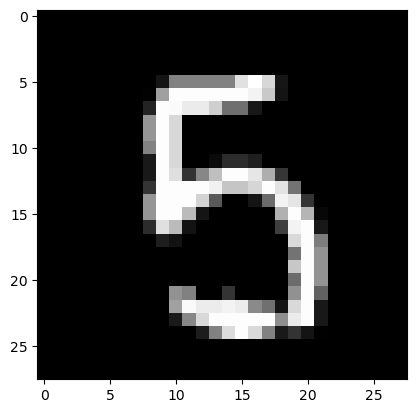

Prediction:  [0]
Label:  0


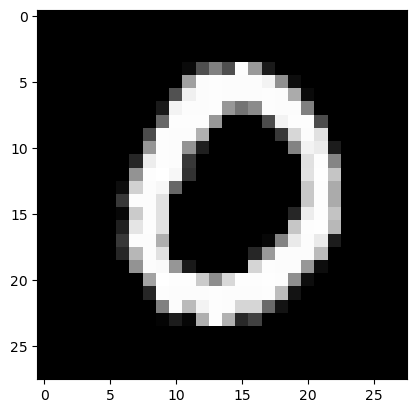

Prediction:  [9]
Label:  9


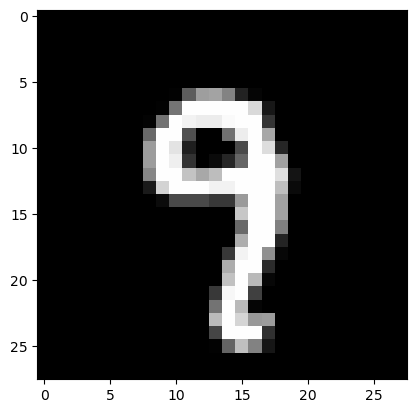

Prediction:  [0]
Label:  0


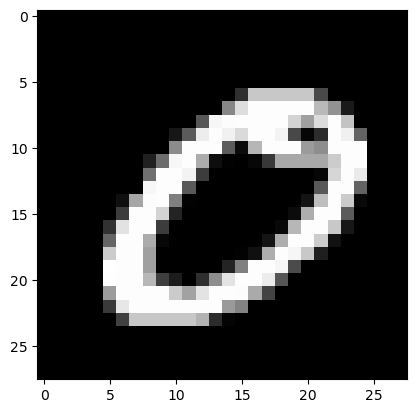

Prediction:  [9]
Label:  9


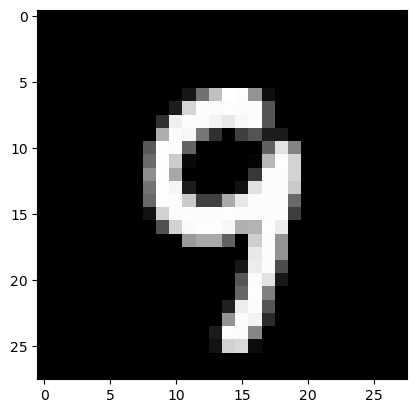

In [38]:
test_prediction(893, W1, b1, W2, b2)
test_prediction(2934, W1, b1, W2, b2)
test_prediction(39585, W1, b1, W2, b2)
test_prediction(4832, W1, b1, W2, b2)
test_prediction(3333, W1, b1, W2, b2)

In [39]:
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
get_accuracy(dev_predictions, Y_dev)

[9 1 1 9 1 8 9 4 7 5 9 3 0 7 9 6 8 3 7 1 1 9 6 2 6 8 1 2 0 9 9 9 3 1 6 0 8
 8 6 5 5 4 8 7 0 0 0 5 2 8 1 6 9 3 0 3 2 4 9 9 2 0 8 4 2 6 5 2 9 5 4 7 2 5
 5 3 0 1 0 8 2 1 1 6 7 5 0 3 0 3 7 1 2 0 6 5 1 0 1 3 9 0 8 2 6 8 8 4 1 1 1
 3 1 5 2 3 3 7 1 9 7 2 7 1 8 5 7 3 4 6 3 7 6 3 4 4 4 2 0 7 2 2 4 7 0 2 2 5
 8 2 8 2 3 5 6 0 7 1 9 3 6 3 5 3 2 4 8 6 7 9 5 1 8 0 1 8 1 5 7 4 7 6 6 7 0
 1 7 7 9 4 5 9 7 3 7 0 6 8 3 8 6 1 1 2 7 2 1 5 6 0 7 8 5 4 1 9 0 3 8 0 8 6
 4 5 7 8 3 7 3 0 7 1 3 3 6 5 1 0 1 5 6 9 6 8 9 8 8 7 2 9 9 7 8 7 6 8 1 9 5
 6 1 6 8 1 7 0 0 6 2 8 1 7 5 0 3 3 2 7 1 4 0 8 6 9 9 2 7 0 8 1 2 7 2 1 6 3
 2 8 2 1 7 3 3 5 8 5 2 9 0 1 7 0 4 9 8 0 6 8 7 3 6 1 2 2 4 4 6 7 2 3 6 5 4
 4 9 4 6 3 6 0 3 1 1 9 7 8 3 8 5 6 6 2 9 0 6 1 3 2 9 0 2 5 9 5 3 5 5 9 9 7
 3 2 0 4 0 4 2 3 9 3 9 7 4 8 7 1 7 9 6 5 7 9 7 2 8 4 2 6 7 1 5 6 9 1 0 9 6
 0 1 5 2 9 9 6 2 0 5 0 0 1 0 2 9 2 7 9 1 1 4 1 2 1 3 9 9 5 0 3 0 6 0 8 0 0
 2 6 2 3 3 7 8 6 8 1 5 3 9 3 9 2 0 5 6 3 3 5 2 0 5 4 9 7 4 1 2 5 3 2 9 6 2
 9 3 9 6 2 9 7 4 7 4 5 4 

0.855